# 0.0. Configure

In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

# 1.0. Imports

In [3]:
from typing import Annotated, Literal, List, TypedDict

from IPython.display import Image, display
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_experimental.utilities import PythonREPL
from langgraph.types import Command
from langchain_community.document_loaders import WebBaseLoader

from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

USER_AGENT environment variable not set, consider setting it to identify your requests.


# 2.0. Hands-On

In [4]:
ddgo_tool = DuckDuckGoSearchResults(max_results=3)

In [5]:
result_test = ddgo_tool.invoke("LLM Agents")

result_test

'snippet: LLM agents offer transformative potential, but addressing challenges such as accuracy, context retention, ethical concerns, and security is crucial for successful implementation. By proactively mitigating these limitations, organizations can build trust, ensure reliability, and maximize the benefits of these powerful tools. ..., title: What Are LLM Agents? Understanding the Power of AI-Driven Systems, link: https://www.tredence.com/blog/llm-agents, snippet: The tools integrated by LLM Agents into various systems Practical Applications of LLM Agents. LLM Agents are widely used across various fields due to their natural language processing capabilities and ability to handle complex tasks: Healthcare: Develops treatment plans based on patient symptoms and history., title: What Is An LLM Agent? How It Works, Advantages & Challenges, link: https://fpt.ai/blogs/llm-agent/, snippet: LLM agents are AI systems that leverage large language models (LLMs) to autonomously perform tasks by

In [6]:
result_test_list = []

for res in result_test.split("link: "):
    if res.startswith("http"):
        result_test_list.append(res.split(",")[0])

In [7]:
WebBaseLoader(result_test_list).load()

[Document(metadata={'source': 'https://www.tredence.com/blog/llm-agents', 'title': 'Access Denied', 'language': 'No language found.'}, page_content='\nAccess Denied\n\nAccess Denied\n \nYou don\'t have permission to access "http://www.tredence.com/blog/llm-agents" on this server.\nReference #18.a7122e17.1737911722.d918ebbe\nhttps://errors.edgesuite.net/18.a7122e17.1737911722.d918ebbe\n\n\n'),
 Document(metadata={'source': 'https://fpt.ai/blogs/llm-agent/', 'title': 'What Is An LLM Agent? How It Works, Advantages & Challenges', 'description': 'LLM Agents are AI Agents that use LLMs as their "brain" to plan, assign tasks, and optimize multi-step processes in business and customer service.', 'language': 'en-US'}, page_content='\n\n\n\n\n\n\n\n\n\n\nWhat Is An LLM Agent? How It Works, Advantages & Challenges\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            Skip to content\n        \n\n\n\n\n\n\n            

In [9]:
[
    f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
    for doc in WebBaseLoader(result_test_list).load()
]

['<Document name="Access Denied">\n\nAccess Denied\n\nAccess Denied\n \nYou don\'t have permission to access "http://www.tredence.com/blog/llm-agents" on this server.\nReference #18.a7122e17.1737911768.d91fada3\nhttps://errors.edgesuite.net/18.a7122e17.1737911768.d91fada3\n\n\n\n</Document>',
 '<Document name="What Is An LLM Agent? How It Works, Advantages & Challenges">\n\n\n\n\n\n\n\n\n\n\n\nWhat Is An LLM Agent? How It Works, Advantages & Challenges\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            Skip to content\n        \n\n\n\n\n\n\n                                About Us\n                            \n\n\n\n\n\n\n\n\n\n                    Introduction\n                \n\n\n\n                    Contact us\n                \n\n\n\n\n\n\n                                Documents\n                            \n\n\n\n\n\n\n\n\n\n\n\n\n                                News\n                          

In [10]:
@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

In [11]:
_TEMP_DIR = TemporaryDirectory()
WORKING_DIR = Path(_TEMP_DIR.name)

_TEMP_DIR, WORKING_DIR

(<TemporaryDirectory '/tmp/tmp9jtvg2e_'>, PosixPath('/tmp/tmp9jtvg2e_'))

In [12]:
@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""

    with (WORKING_DIR / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")

    return f"Outline saved to {file_name}"

In [13]:
@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIR / file_name).open("r") as file:
        lines = file.readlines()

    if start is not None:
        start = 0

    return "\n".join(lines[start:end])

In [14]:
@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIR / file_name).open("w") as file:
        file.write(content)

    return f"Document saved to {file_name}"

In [15]:
@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIR / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIR / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

In [16]:
repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    return f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"

In [17]:
class State(MessagesState):
    next: str

In [18]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [19]:
research_members = ["search", "web_scraper"]
research_system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {research_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

In [20]:
class ResearchRouter(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["search", "web_scraper", "FINISH"]

In [21]:
def research_supervisor_node(state: State) -> Command[Literal["search", "web_scraper", "__end__"]]:
    """An LLM-based router."""
    messages = [
        {"role": "system", "content": research_system_prompt},
    ] + state["messages"]

    response = llm.with_structured_output(ResearchRouter).invoke(messages)
    goto = response["next"]

    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [22]:
search_agent = create_react_agent(llm, tools=[ddgo_tool])

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="search")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [23]:
web_scraper_agent = create_react_agent(llm, tools=[scrape_webpages])

def web_scraper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scraper_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="web_scraper")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [24]:
research_builder = StateGraph(State)

research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)

research_builder.add_edge(START, "supervisor")

research_graph = research_builder.compile()

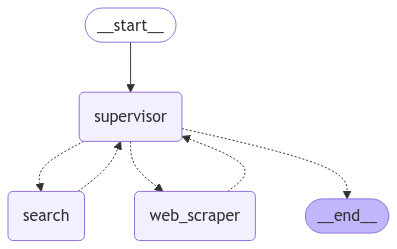

In [25]:
display(Image(research_graph.get_graph().draw_mermaid_png()))

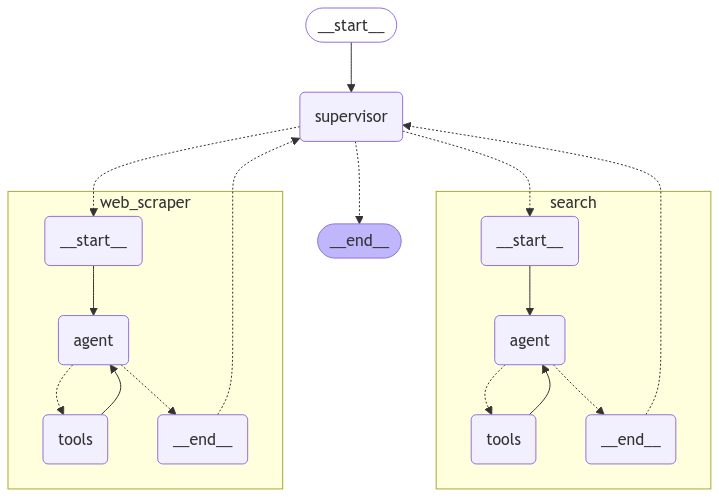

In [26]:
display(Image(research_graph.get_graph(xray=True).draw_mermaid_png()))

In [27]:
doc_writer_agent = create_react_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    state_modifier=(
        "You can read, write and edit documents based on note-taker's outlines. "
        "Don't ask follow-up questions."
    ),
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="doc_writer")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [28]:
note_taking_agent = create_react_agent(
    llm,
    tools=[create_outline, read_document],
    state_modifier=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    ),
)

def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="note_taker")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


In [29]:
chart_generating_agent = create_react_agent(
    llm, tools=[read_document, python_repl_tool]
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=result["messages"][-1].content, name="chart_generator"
                )
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [30]:
doc_members = ["doc_writer", "note_taker", "chart_generator"]
doc_system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {doc_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

In [31]:
class DocRouter(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["doc_writer", "note_taker", "chart_generator", "FINISH"]

In [32]:
def doc_supervisor_node(state: State) -> Command[Literal["doc_writer", "note_taker", "chart_generator", "__end__"]]:
    """An LLM-based router."""
    messages = [
        {"role": "system", "content": doc_system_prompt},
    ] + state["messages"]

    response = llm.with_structured_output(DocRouter).invoke(messages)
    goto = response["next"]

    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [33]:
paper_writing_builder = StateGraph(State)

paper_writing_builder.add_node("supervisor", doc_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")

paper_writing_graph = paper_writing_builder.compile()

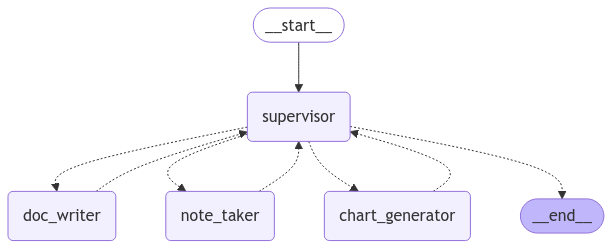

In [34]:
display(Image(paper_writing_graph.get_graph().draw_mermaid_png()))

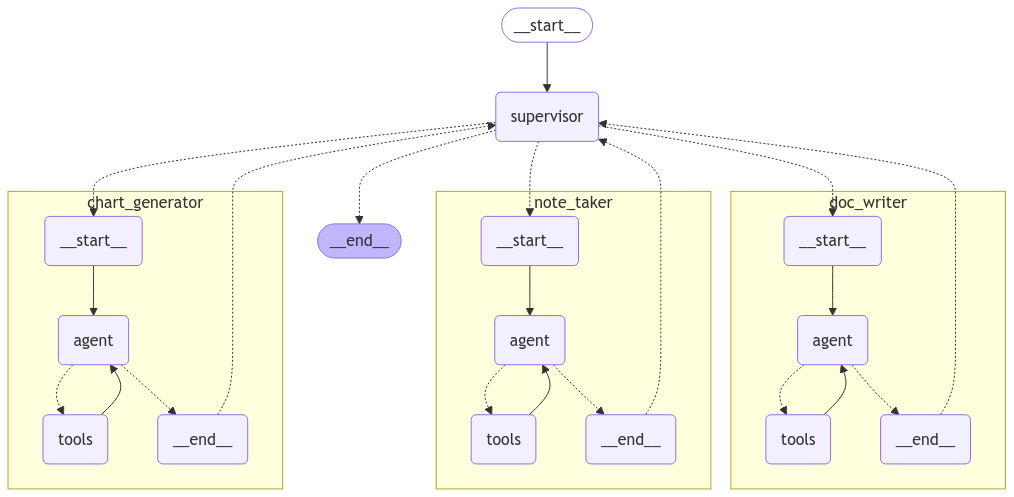

In [35]:
display(Image(paper_writing_graph.get_graph(xray=True).draw_mermaid_png()))

In [36]:
teams_members = ["research_team", "writing_team"]
teams_system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {teams_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

In [37]:
class TeamsRouter(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["research_team", "writing_team", "FINISH"]

In [38]:
def teams_supervisor_node(state: State) -> Command[Literal["research_team", "writing_team", "__end__"]]:
    """An LLM-based router."""
    messages = [
        {"role": "system", "content": teams_system_prompt},
    ] + state["messages"]

    response = llm.with_structured_output(TeamsRouter).invoke(messages)
    goto = response["next"]

    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [39]:
def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )

In [40]:
def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )

In [41]:
super_builder = StateGraph(State)

super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

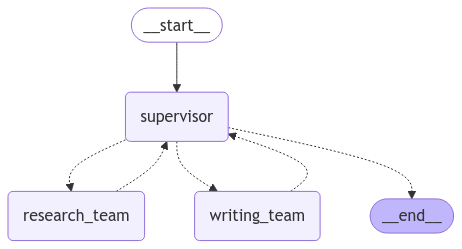

In [42]:
display(Image(super_graph.get_graph().draw_mermaid_png()))

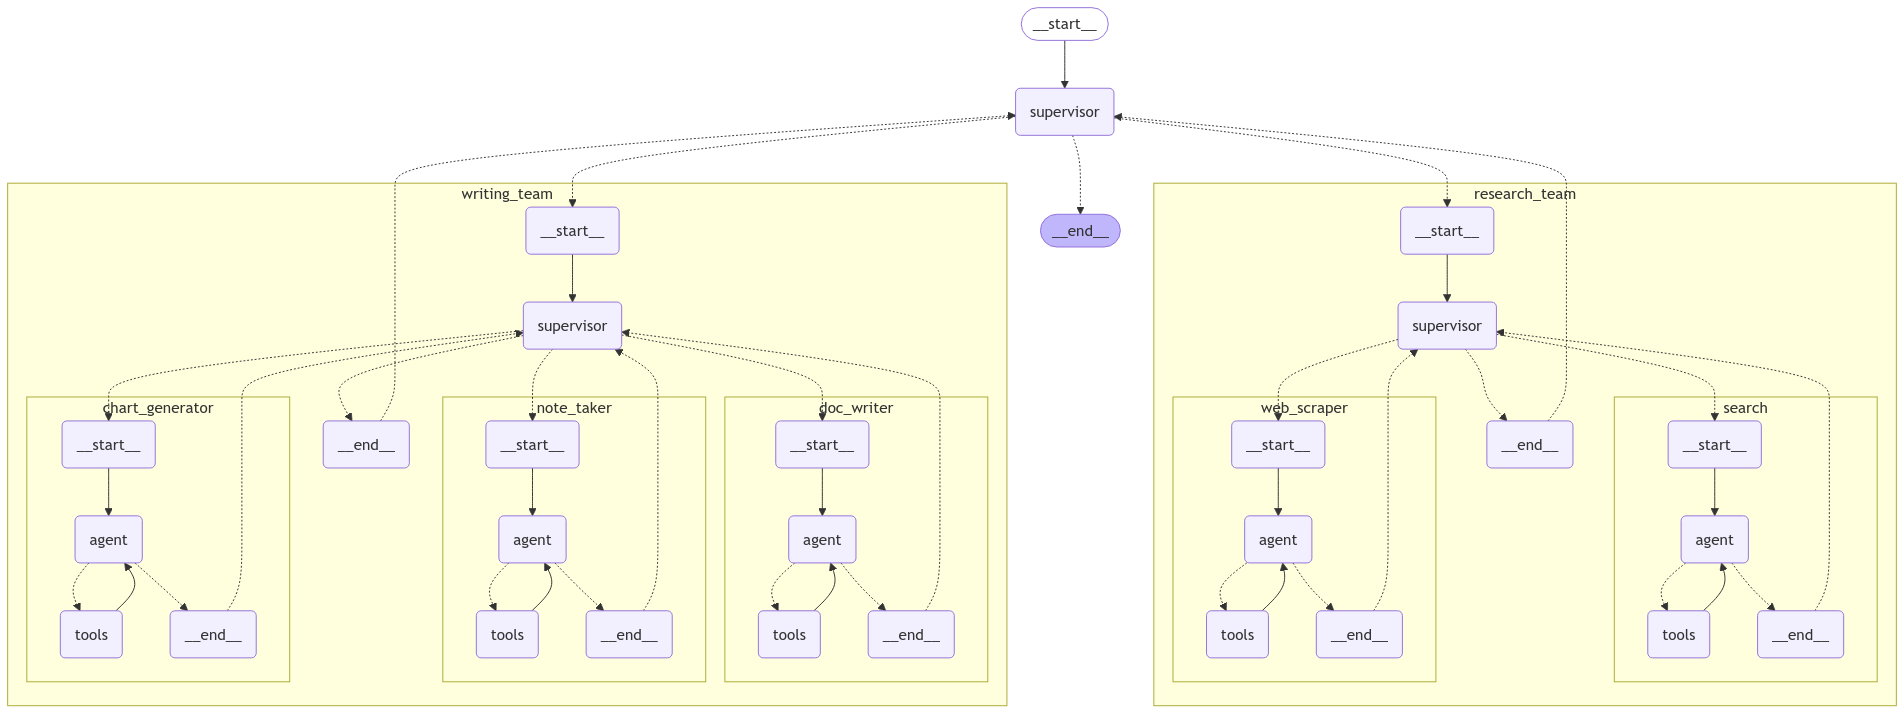

In [43]:
display(Image(super_graph.get_graph(xray=True).draw_mermaid_png()))

# 3.0. Testing

In [44]:
for s in research_graph.stream(
    {
        "messages": [
            (
                "user",
                "when is Taylor Swift's next tour?"
            )
        ]
    },
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content="Taylor Swift's next tour, the Eras Tour, will resume in 2024. The first concert of the year is scheduled for February 7 in Tokyo at the Tokyo Dome. The tour will then continue with dates in Asia, Australia, Europe, and Canada throughout the year.\n\nFor the full schedule, you can find more details [here](https://www.thepinknews.com/2024/02/01/taylor-swift-tour-dates-2024/).", additional_kwargs={}, response_metadata={}, name='search', id='e69188c9-4dad-44c5-8728-6339bd5039f6')]}}
---
{'supervisor': {'next': '__end__'}}
---


In [45]:
for s in paper_writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for poem about cats and then write the poem to disk.",
            )
        ]
    },
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The outline for the poem about cats has been saved, along with the poem itself. \n\n- **Outline saved:** cat_poem_outline.txt\n- **Poem saved:** cat_poem.txt', additional_kwargs={}, response_metadata={}, name='doc_writer', id='1e2732ae-e0a5-4fc6-9510-a75c8bd85a77')]}}
---
{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content="The outline for the poem about cats has been saved successfully as **cat_poem_outline.txt**. The poem titled **Whiskers and Whimsy** has also been written and saved to **cat_poem.txt**. Here is the poem:\n\n---\n\n**Whiskers and Whimsy**\n\nIn shadows soft, where mysteries play,  \nDwell creatures sleek, at the end of the day.  \nWith fur that glistens like stars in the night,  \nCats roam the world with a graceful delight.  \n\nTheir eyes are lanterns, glowing so bright,  \nReflecting the secrets of the moon's gentle light.  \nA pat

In [46]:
for s in super_graph.stream(
    {
        "messages": [
            ("user", "Research AI agents and write a brief report about them.")
        ],
    },
    {"recursion_limit": 150},
):
    print(s)
    print("---")

{'supervisor': {'next': 'research_team'}}
---
{'research_team': {'messages': [HumanMessage(content='### Report on AI Agents\n\n**Definition of AI Agents**\nArtificial Intelligence (AI) agents are autonomous systems or programs designed to perform tasks on behalf of users or other systems. They operate based on the ability to make decisions and achieve specific goals with minimal human intervention.\n\n**Technology and Functionality**\nAI agents leverage generative AI models and large language models to interact effectively with users or systems. They are capable of adapting to different tasks, from simple repetitive actions to complex problem-solving scenarios. The advancement of machine learning technologies has empowered these agents to learn from their experiences and enhance performance over time.\n\n**Types of AI Agents**\nAI agents can be categorized based on their functionality:\n\n1. **Reactive Agents:** These agents respond to stimuli in real-time without retaining memory of p